# 1. Сформулировать постановку задачи, которую хочется решать в рамках курса.


*   Бизнес-постановка задачи:
Нужно предсказать какие клиенты телеком-компании собираются уйти, чтобы предложить им индивидуальные акции, различные целенеправленные программы удержания, чтобы удержать клиента/снизить отток.

*   ML постановка задачи:
Задача бинарной классификации, где 1-клиент уйдёт, 0-останется

*   Набор данных:
Источник: Kaggle - https://www.kaggle.com/datasets/blastchar/telco-customer-churn/data

  В датасете - 7043 строк, 21 столбец, из них 19 признаков. Исходный столбец "Churn" наша целевая метка

## Ниже следующие пункты 2), 3)  и их описание вместе с кодом.



In [3]:
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
import phik

In [5]:
df = pd.read_csv("Telco-Customer-Churn.csv")

In [6]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# 2. Выбрать и обосновать метрику для измерения качества.



In [7]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Видим, что классы несбалансированы, accuracy здесь точно будет не так полезна. Ориентируясь на метрики классификации, нужно взять в первую очередь Recall, так как он будет показывать какую долю действительно ушедших клиентов мы правильно предсказали. Нам важно не пропустить клиентов, которых можно попытаться удержать(то есть минимизировать FN-False Negative)
Также можно будет смотреть F1-Score, который балансирует между Precision и Recall

# 3.Провести EDA на своих данных
В рамках данного пункта необходимо провести предварительный разведочный анализ своего набора данных.


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Выведя информацию о датафрейме, можно сделать вывод, что большинство признаков категориальные(тип - object), либо некоторые из них, например, как TotalCharges(понятно из df.head()) имеет числовые значения, но есть, возможно, какие-то нечисловые значения, что даёт ему тип object

In [10]:
df = df.drop("customerID",axis=1)

In [11]:
df.isna().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Проверив столбцы на такие пропуски как np.nan, None, ничего не обнаружено

In [12]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"].dtypes

dtype('float64')

In [13]:
df["TotalCharges"].isna().sum()

11

Приведя наш признак из типа object в числовой и обработав различные ошибки с помощью аргумента errors="coerce" в Nan, а после снова проверив на различные пропущенные значения, мы получили 11 пропущенных значений NaN в столбце TotalCharges

In [14]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


Выведя информацию о числовых признаках, можно сделать вывод, что SeniorCitizen это просто бинарный категориальный признак 0/1 пожилой гражданин или нет.

tenure - время пользования услугами довольно сильно отличается, кто-то пользовался меньше месяца, а кто-то на протяжении 6 лет

MonthlyCharges - ежемесячные платяжи, min and max тоже сильно отличаются между собой, как и в TotalCharges у которого очень огромный разброс относительно среднего и большое смещение среднего вправо относительно медианы

In [15]:
num_cols = df.select_dtypes(exclude='object')
num_cols = num_cols.drop("SeniorCitizen",axis=1)
num_cols.shape

(7043, 3)

In [16]:
fig = px.pie(df, names='Churn', title='Распределение клиентов по оттоку',
             color_discrete_sequence=px.colors.qualitative.Set2)
fig.update_traces(textposition='inside', textinfo='percent+label')
fig.show()

Круговая диаграмма наглядно показывает, что примерно 1/4 клиентов в нашей выборке отказываются от продуктов телеком компании.

C:\Users\Marsohodik\AppData\Roaming\Python\Python312\site-packages\seaborn\_base.py:948: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.

C:\Users\Marsohodik\AppData\Roaming\Python\Python312\site-packages\seaborn\_base.py:948: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.

C:\Users\Marsohodik\AppData\Roaming\Python\Python312\site-packages\seaborn\_base.py:948: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.



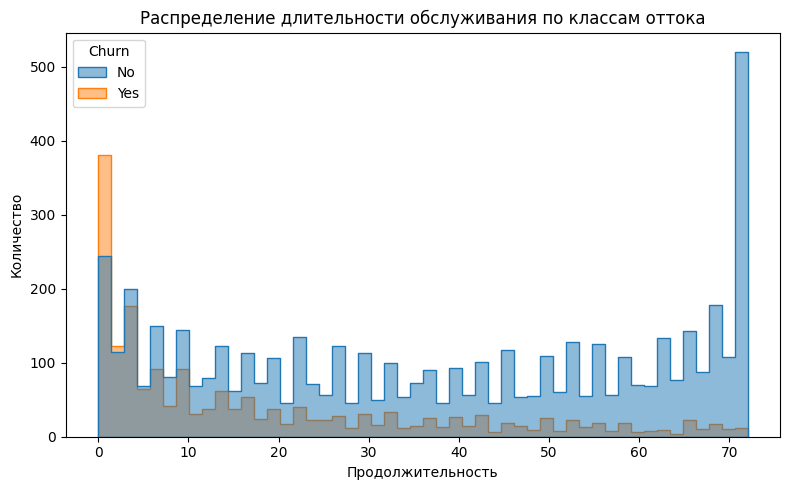

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(df, x='tenure', hue='Churn', bins=50, element='step',alpha=0.5)

plt.title('Распределение длительности обслуживания по классам оттока')
plt.xlabel('Продолжительность')
plt.ylabel('Количество')
plt.tight_layout()
plt.show()

Гистограмма показывает, что отток сильно выше у клиентов с коротким сроком обслуживания, чем у клиентов, которые находятся долго с компанией. В будущем нам нужно будет фокусироваться именно на этих клиентах, так как они уходят чаще всего. Проверять качество модели отдельно для новых и постоянных клиентов

In [18]:
fig = px.scatter(df, x='tenure', y='MonthlyCharges', color='Churn', title='Зависимость оттока от длительности и ежемесячной платы', hover_data=['Contract', 'InternetService'])
fig.show()

По данной визуализации можно сделать вывод, что клиенты уходят не только просто с самым коротким сроком обслуживания, но также клиенты, которые имеют высокие ежемесячные платежи уходят чаще, чем клиенты чей ежемесячный платёж меньше

In [19]:
#Возьмём категориальные переменные
cat_cols = df.select_dtypes(include='object')
cat_cols.head()

,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
0,Female,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,No
1,Male,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,No
2,Male,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,Yes
3,Male,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),No
4,Female,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,Yes


In [20]:
cat_cols.describe()

,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
freq,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,5174


Многие из категориальных переменных являются бинарными, либо также имеют небольшое кол-во уникальных значений. Бинарные признаки стоит преодработать просто LabelEncoder-ом в 0/1, а остальные признаки так как у них не так много уникальных значений и признаковое пространство будет не сильно раздутым, то можно попробовать с помощью one-hot encoding

In [21]:
fig = px.bar(df, x='Contract', color='Churn',
             title='Тип контракта и факт оттока',
             barmode='group', text_auto=True,
             color_discrete_sequence= ["#66FF00", "#C70039"])
fig.show()

Клиенты с month-to-month контрактом имеют наибольший отток, чем клиенты с более длительным контрактом на предоставление сервиса.

In [22]:
pd.crosstab(df['PaymentMethod'], df['Churn'], margins=True).style.background_gradient(cmap='summer_r')

Churn,No,Yes,All
PaymentMethod,,,
Bank transfer (automatic),1286,258,1544
Credit card (automatic),1290,232,1522
Electronic check,1294,1071,2365
Mailed check,1304,308,1612
All,5174,1869,7043


Люди оплатившие чеком имеют самый высокий процент оттока среди всех методов оплаты. В целом среди всех ушедших клиентов больше половины приходится именно на этот метод оплаты. Это говорит о том, что, возможно, нужно ориентировать фокус клиентов с чеков на автоматические методы оплаты, когда операции проходят автоматически и быстро

# Зависимость с переменными

Так как у нас ещё не преодработка признаков, то закодируем пока все категориальные признаки в LabelEncoding для дальнейшего исследования EDA, а на предоработке уже сделаем как надо

In [23]:
#Закодируем категории
NEED_LABEL_ENCODING = True
if NEED_LABEL_ENCODING:
    le = LabelEncoder()
    for c in cat_cols.columns:
        df[c] = le.fit_transform(cat_cols[c])
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


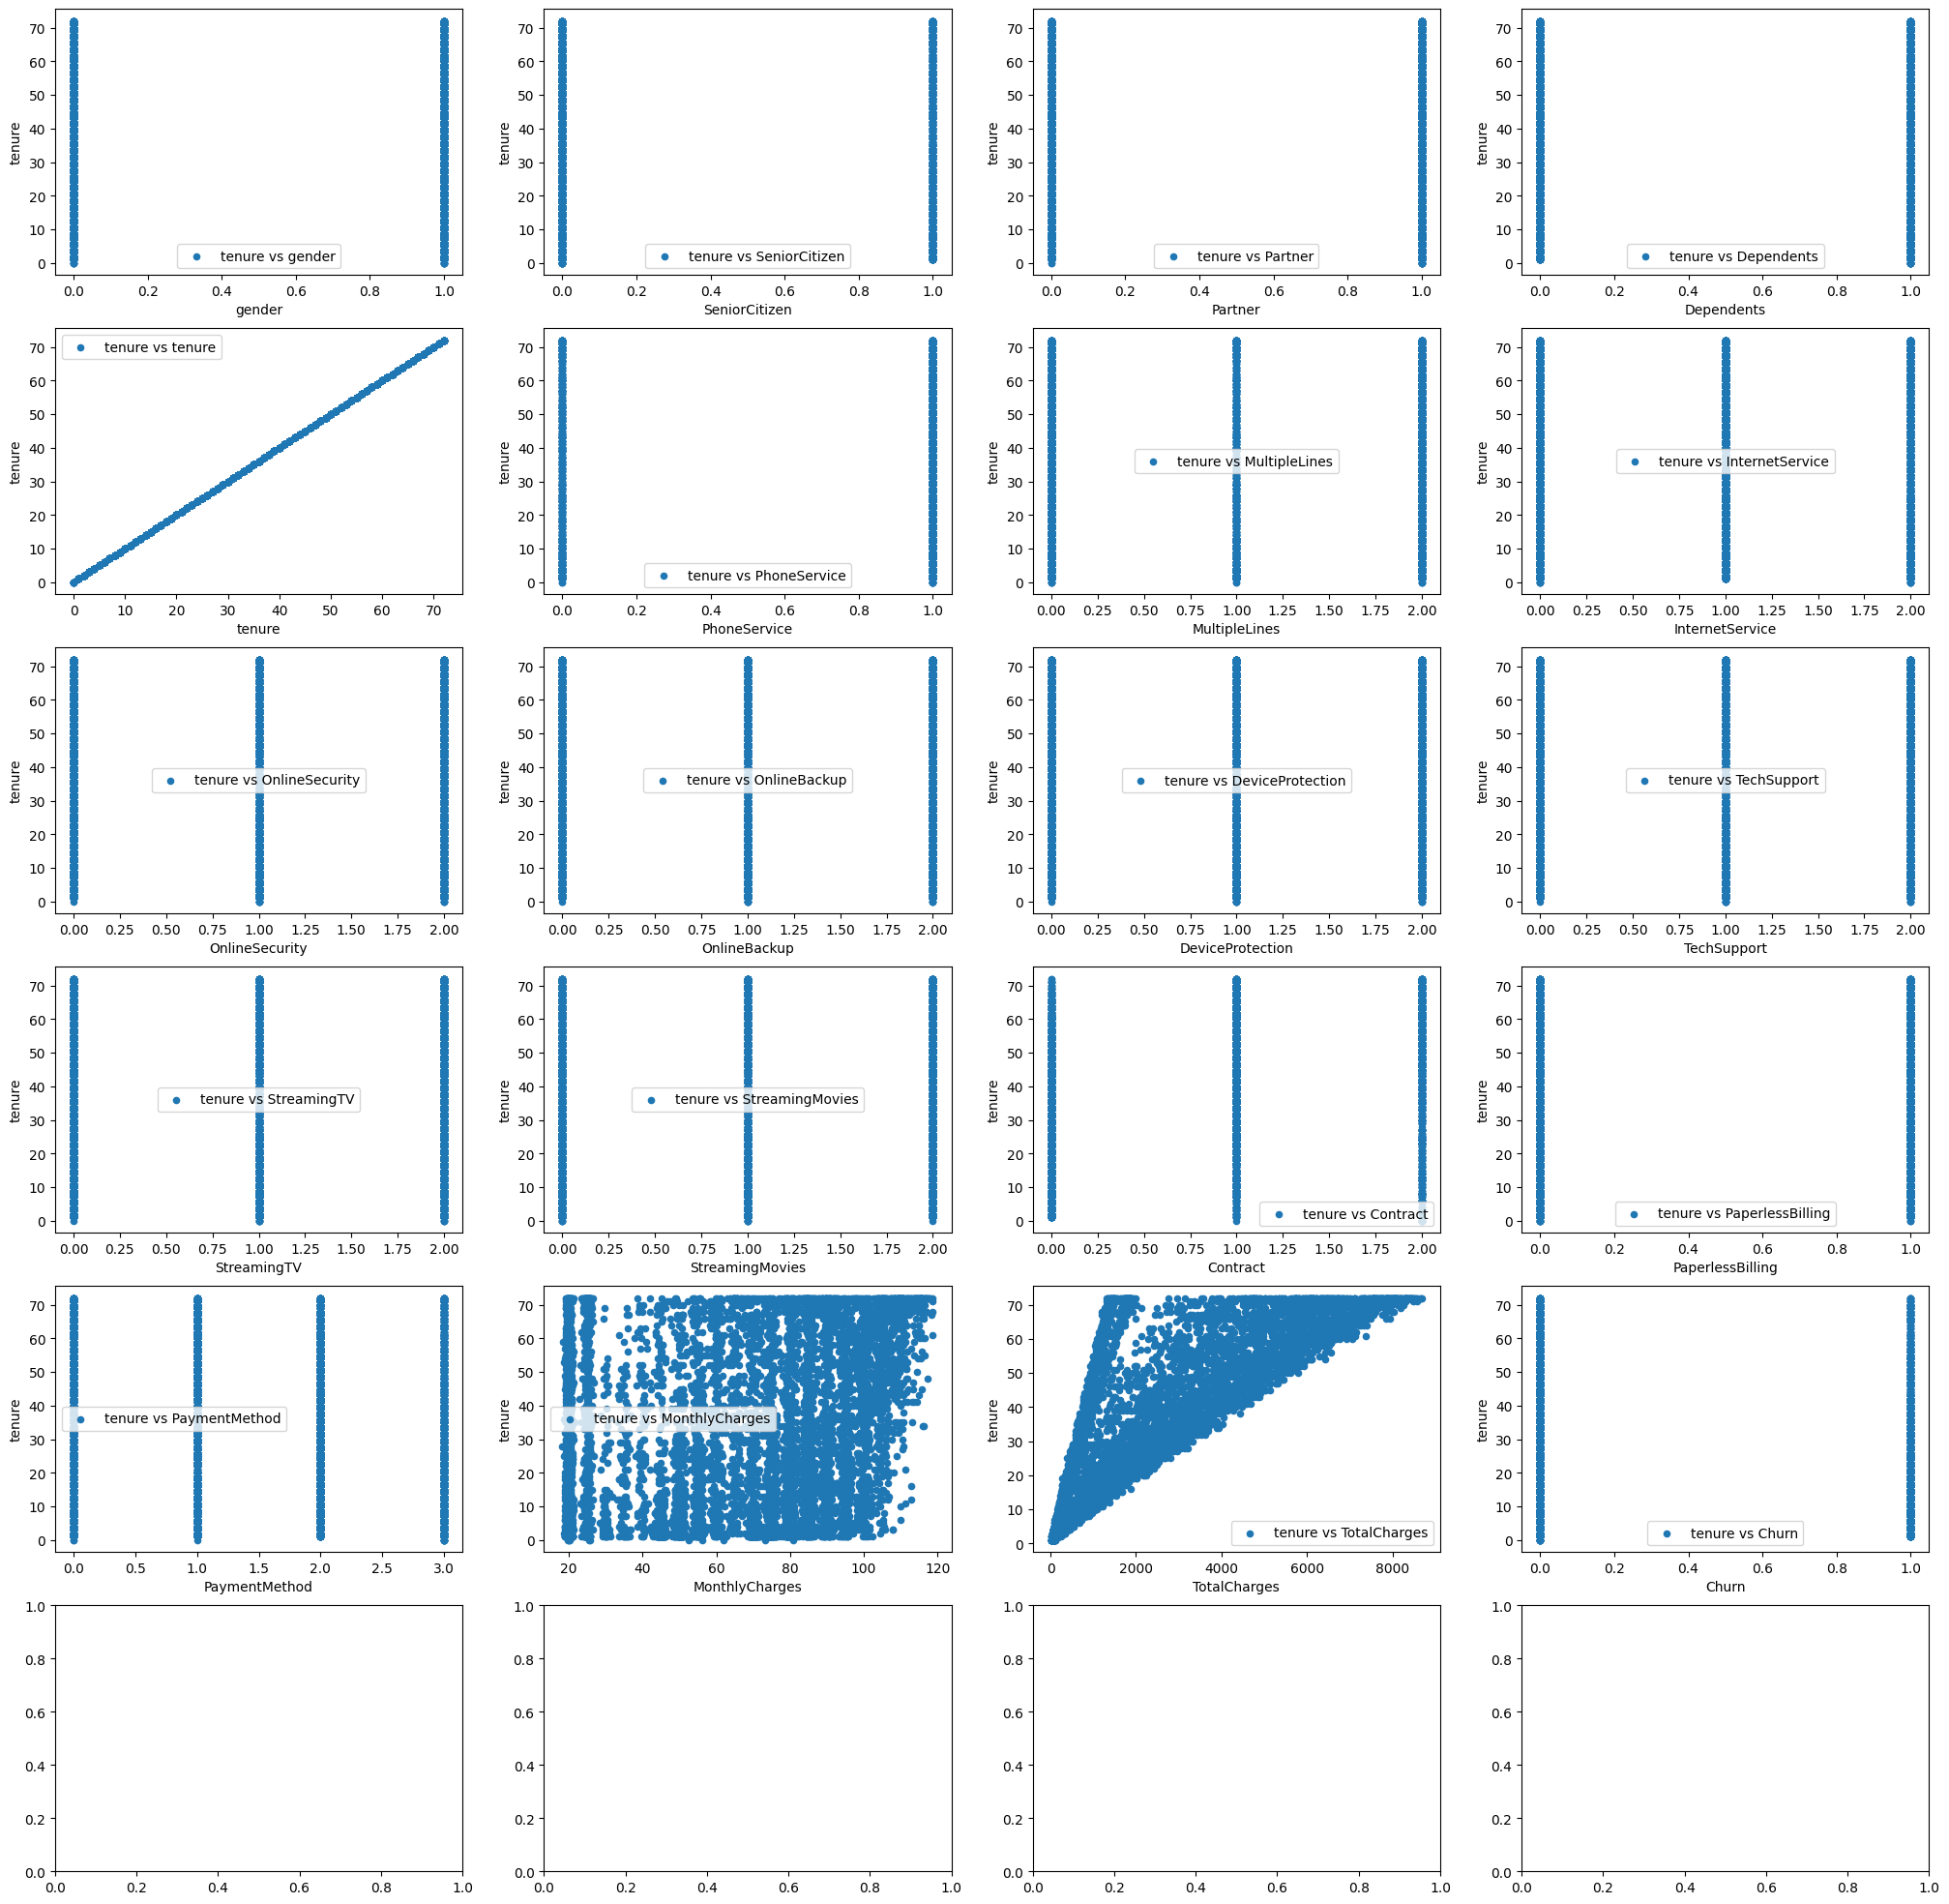

In [24]:
fig, axes = plt.subplots(nrows=6, ncols=4, figsize=(25, 25))
for idx, feature in enumerate(df.columns):
    df.plot(feature, "tenure", subplots=True, kind="scatter", ax=axes[idx // 4, idx % 4], label=f'tenure vs {feature}')

Сложно дать какие-либо выводы по полученным данным кроме всё той же зависимости tenure - TotalCharges, что с увеличением полной оплаты за услуги компании, растёт и кол-во времени пользования этими услугами

## Выбросы

C:\Users\Marsohodik\AppData\Roaming\Python\Python312\site-packages\seaborn\categorical.py:632: FutureWarning:

SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.

C:\Users\Marsohodik\AppData\Roaming\Python\Python312\site-packages\seaborn\categorical.py:632: FutureWarning:

SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.

C:\Users\Marsohodik\AppData\Roaming\Python\Python312\site-packages\seaborn\categorical.py:632: FutureWarning:

SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.



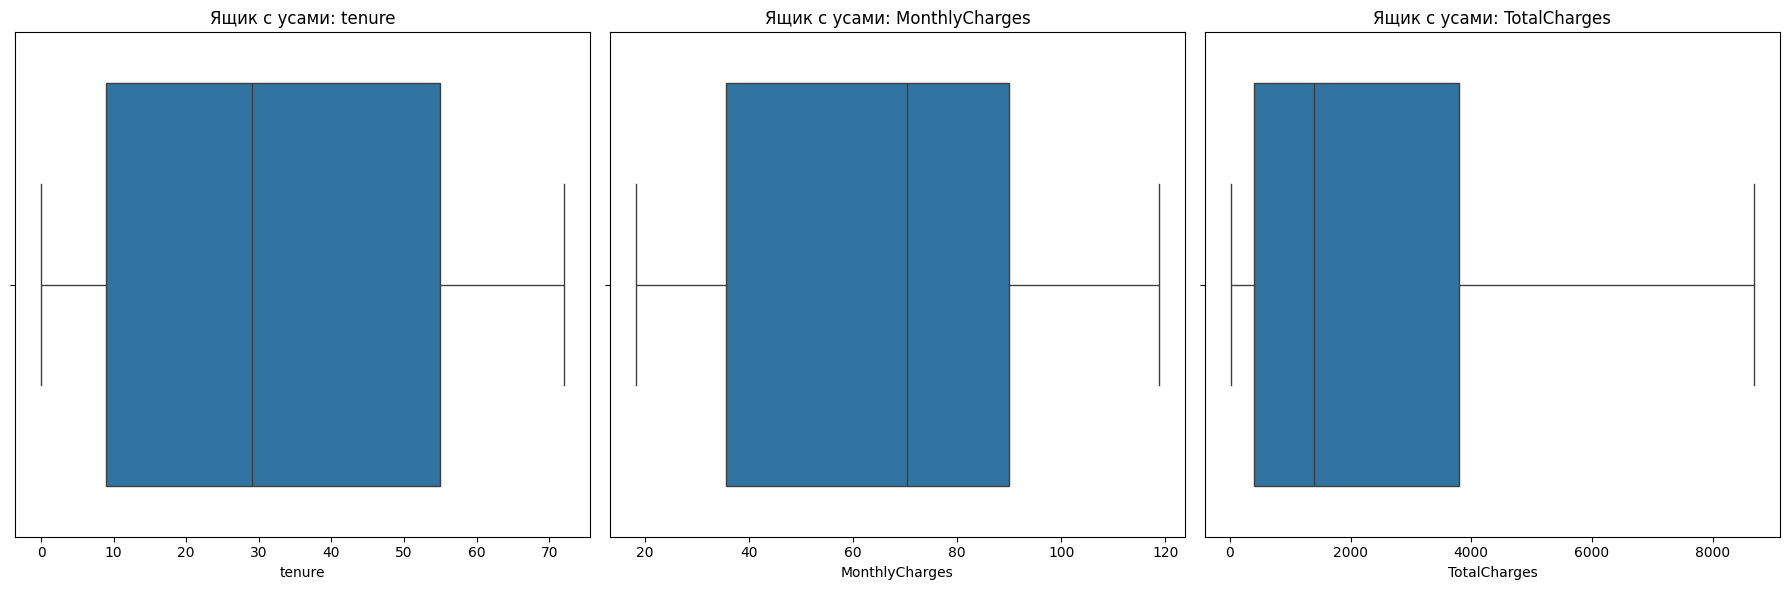

In [25]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 6))

for idx, feature in enumerate(num_cols.columns):
    sns.boxplot(x=df[feature], ax=axes[idx])
    axes[idx].set_title(f'Ящик с усами: {feature}')

plt.tight_layout()
plt.show()

В целом нет явных выбросов - все данные в пределах усов.

У tenure(продолжительности) довольно всё равномерно с небольшим смещением вправо

У MonthlyCharges(ежемемесячные платежи) - тарифы имеют разумные пределы, возможно за 20 - это какой-то бюджетный вариант, а за 120 премиальный.

У TotalCharges большой разброс,  есть клиенты с очень высокими общими платежами, которые находятся в компании длительное время

## Распределения числовых признаков

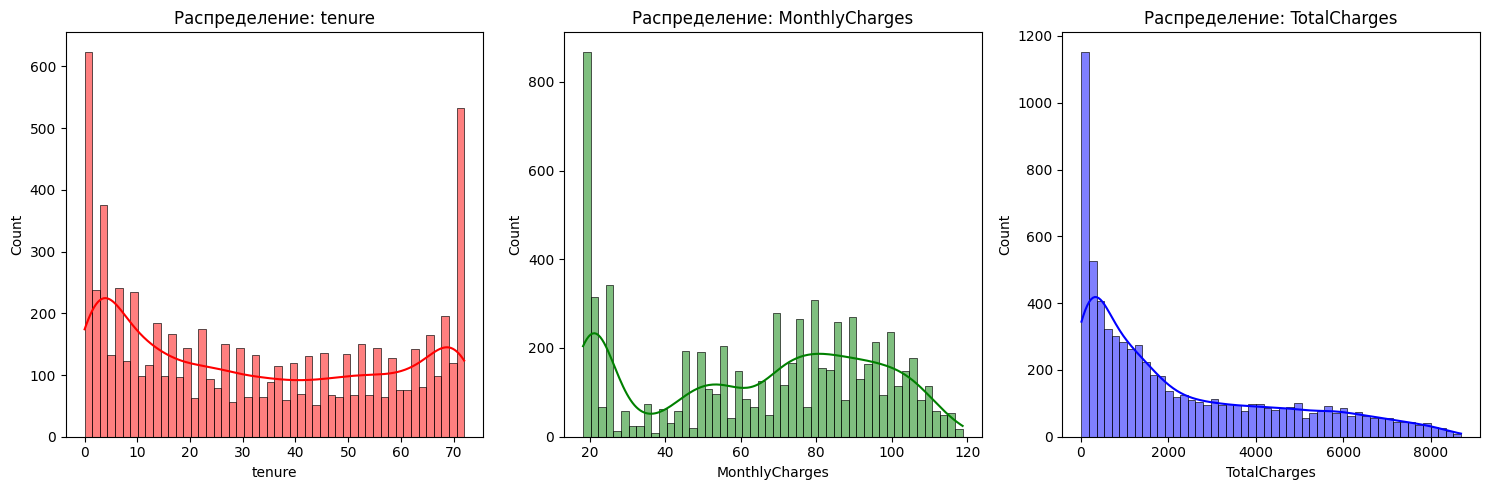

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ['r', 'g', 'b']

for i, (ax, feature, color) in enumerate(zip(axes, num_cols.columns, colors)):
    sns.histplot(df[feature], bins=50, color=color, ax=ax, kde = True)
    ax.set_title(f"Распределение: {feature}")

plt.tight_layout()
plt.show()

По распределению tenure(кол-во месяцев пользования) можно сказать, что данные не сконцентрированы вокруг одного значения. Можно выделить несколько дискретных групп: 0-10, 10-30, 30-50, 50-70 месяцев

По распределению MonthlyCharges(ежемесячная оплата) также можно сказать, что есть какая-то сегментация по оплате в месяц, то есть можно выделить группы от 20 до 60, 60-100, 100-120 и с этим работать

По распределению TotalCharges(полная оплата) можно сказать, что большинство клиентов сосредоточены в низком диапазоне платежей, то есть клиенты имеют короткий срок пользования продуктами компании за весь период, либо просто клиенты ещё новые, xвост уходит вправо из-за долгосрочных клиентов с высокой общей оплатой.

## Корреляция

interval columns not set, guessing: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


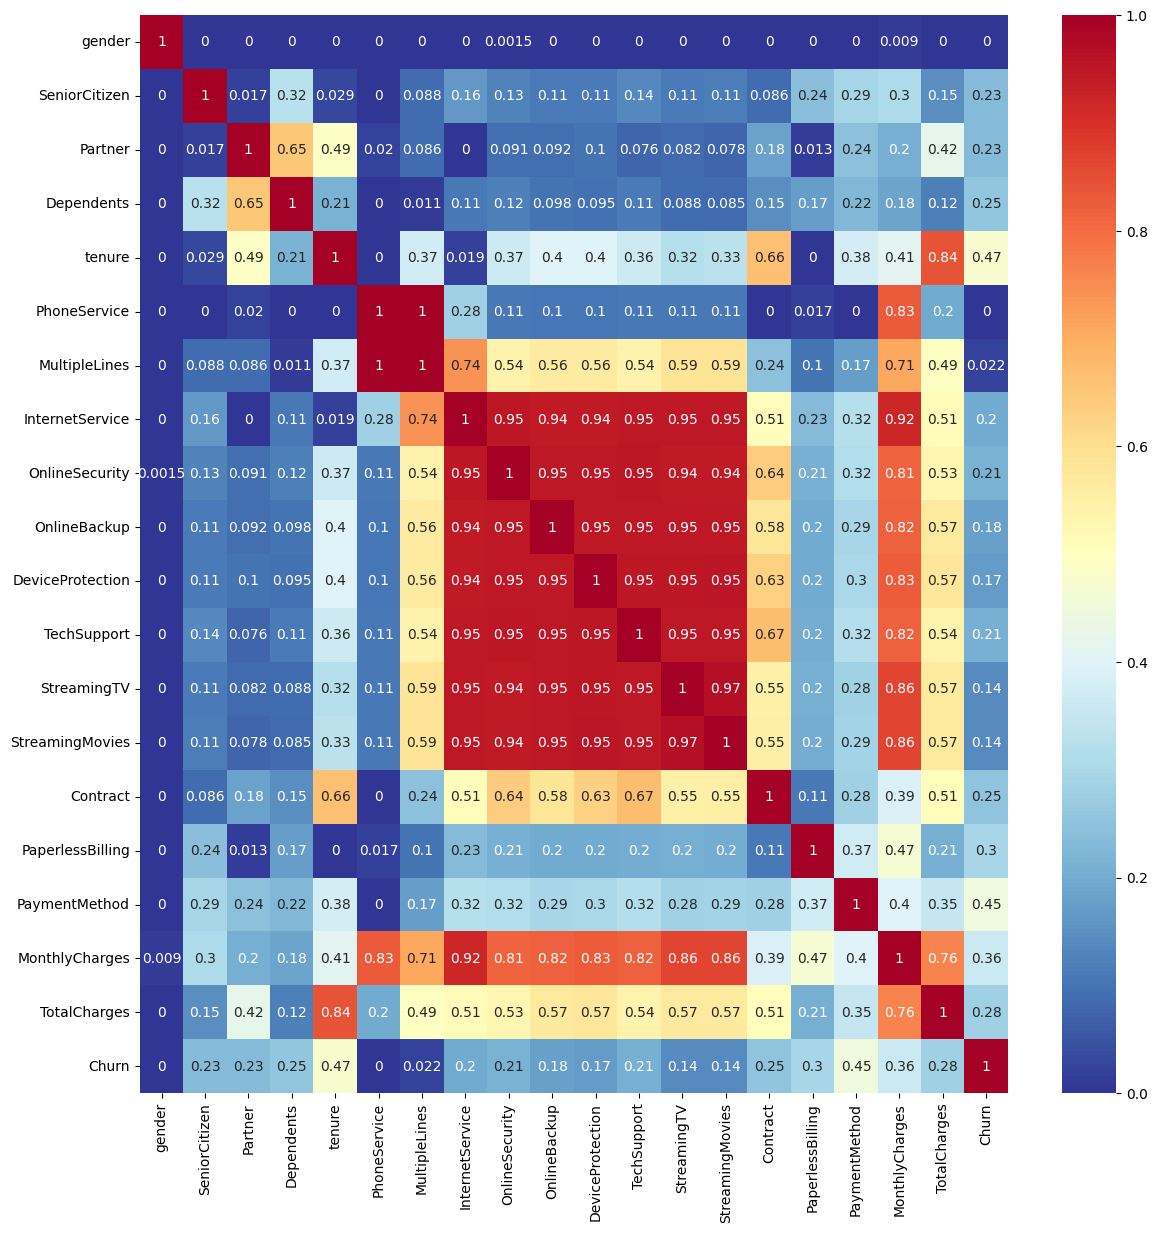

In [27]:
plt.figure(figsize=(14, 14))
sns.heatmap(df.phik_matrix(), cmap="RdYlBu_r", annot=True);

По проведенному анализу взаимосвязей между признаками на основе матрицы корреляций можно сделать вывод, что признаки, характеризующие подключение дополнительных интернет-сервисов (OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies), демонстрируют крайне высокую степень взаимной корреляции. Поэтому в дальнейшем для уменьшения размерности признакого пространства, борьбы с переобучением и т.д, можно удалить какие-либо из указанных признаков, либо агрегировать их в какой-то новый по какому-либо условию.

Среди признаков, имеющих наибольшую степень связи с таргетом Сhurn, выделяются tenure, PaymentMethod, что позволяет считать их релевантными для дальнейшего использования в модели.

Признаки gender, SeniorCitizen, Partner, Dependents и PhoneService характеризуются крайне слабой связью как с таргетом, так и с другими признаками, что указывает возможно на их дальнейшее удаление из признакового пространства.

Признак TotalCharges имеет высокую связь с tenure, что также подтверждалось и исследованиями выше.

